In [8]:
import re
import pandas as pd

with open('massive docx.txt', 'r') as f: # 1. Continue making the dataset you began in class-- the dataset should have 1 column and at least 1000 rows, each row should be a sentence from your own writing. 


    text = f.read()

sentences = re.split(r'(?<=[.?!])\s+', text.strip())

df = pd.DataFrame(sentences, columns=['sentence'])
df['cleantext'] = df['sentence'].str.lower() #2. Create a new column called “clean_text.” Convert all text to lowercase. 

punctuation_numbers_extraspaces = set(['.', '?', '!', ',', ';', ':', '-', '(', ')', '[', ']', 
                                        '{', '}', '"', "'", '0', '1', '2', '3', '4', '5', 
                                        '6', '7', '8', '9'])

df['nopunc'] = df['cleantext'].apply( 
    lambda sentence: ''.join(i for i in sentence if i not in punctuation_numbers_extraspaces)
)
print(df[['sentence','nopunc']].head(1))
#3. Remove punctuation, numbers, and extra spaces from the writing samples. Compare one original sentence and one cleaned sentence.

df.head()
df['nopunc']=df['nopunc'].str.strip() 
# 4. Tokenize each sentence into individual words. What does tokenization do to a sentence?

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
stop_words = ENGLISH_STOP_WORDS
df['simple'] = df['nopunc'].apply(
    lambda sentence: ' '.join(word for word in sentence.split() if word not in stop_words)
)  
df.head()
# 5. Remove common stop words (such as “the,” “and,” “is,” “of”). Do this by finding the list of common stop words in sci-kit learn, importing it, and then removing those words from each of your rows.  Try to actually write this code yourself using iteration (a for loop!). 




                                            sentence  \
0  ﻿Allegory of the Cave: Implications of the Ana...   

                                              nopunc  
0  ﻿allegory of the cave implications of the anal...  


,sentence,cleantext,nopunc,simple
0,﻿Allegory of the Cave: Implications of the Ana...,﻿allegory of the cave: implications of the ana...,﻿allegory of the cave implications of the anal...,﻿allegory cave implications analogies sun line...
1,The forms is what Plato considers true knowledge.,the forms is what plato considers true knowledge.,the forms is what plato considers true knowledge,forms plato considers true knowledge
2,"This journey isn’t just a one way path up, the...","this journey isn’t just a one way path up, the...",this journey isn’t just a one way path up the ...,journey isn’t just way path journey reach full...
3,"As a result, Plato believes only Philosophers ...","as a result, plato believes only philosophers ...",as a result plato believes only philosophers a...,result plato believes philosophers truly attai...
4,Taking this belief and applying it in his cons...,taking this belief and applying it in his cons...,taking this belief and applying it in his cons...,taking belief applying construction ideal stat...


war           60
slavery       42
knowledge     41
people        41
just          38
dirt          38
black         33
life          31
loved         29
things        29
great         29
louverture    27
result        27
like          27
world         26
dtype: int64


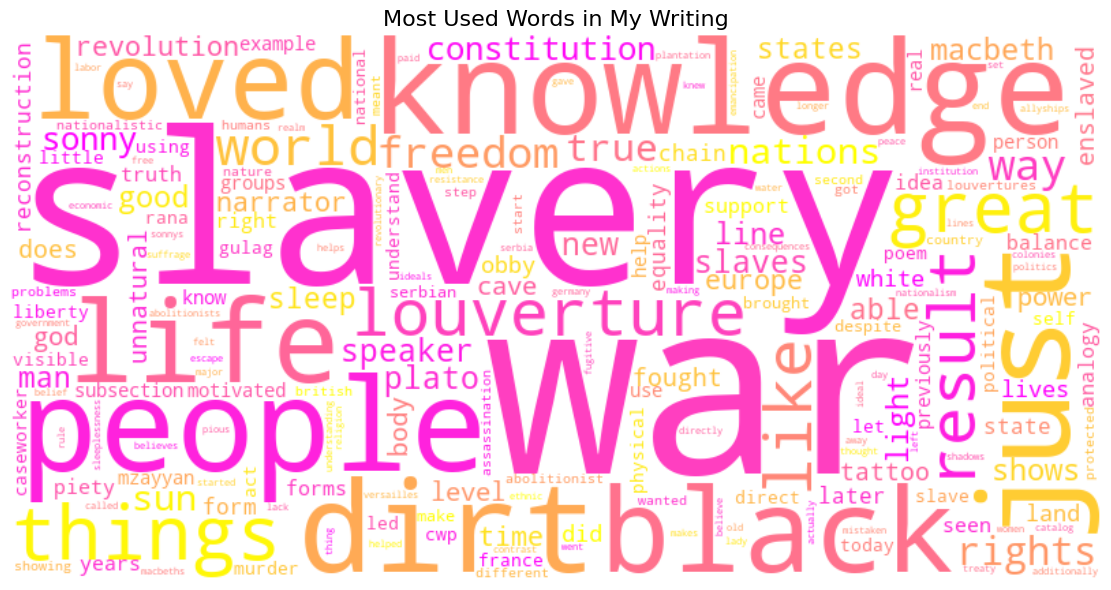

In [6]:
# 6. Bag of Words representation
from sklearn.feature_extraction.text import CountVectorizer

df['doc_id'] = df.index // 10

documents = df.groupby('doc_id')['simple'].apply(lambda x: ' '.join(x)).reset_index()
documents.columns = ['doc_id', 'text']

vectorizer = CountVectorizer()
bow_matrix = vectorizer.fit_transform(documents['text'])


bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=vectorizer.get_feature_names_out()
)

#7. Identify the words with the highest total counts across all writing samples. Which words dominate your writing most strongly?
word_totals = bow_df.sum().sort_values(ascending=False)
print(word_totals.head(15))  #

# 8. Word cloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

word_freq = word_totals.to_dict()

wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white',
    colormap='spring'
).generate_from_frequencies(word_freq)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Used Words in My Writing', fontsize=16)
plt.tight_layout()
plt.show()

In [3]:
#9. Apply TF-IDF vectorization to the cleaned text. How is TF-IDF different from simple word counts?
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df['simple'])
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)
print(tfidf_df.shape)
tfidf_df.head()


(666, 2900)


,abide,abilities,ability,ablaze,able,abolish,abolished,abolishing,abolition,abolitionist,...,yard,year,yearn,years,yelled,you,young,younger,youth,youthful
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
#10. Find the highest TF-IDF words in your dataset. Which words are more unique or meaningful compared to the overall corpus?

highesttfidf = tfidf_df.sum().sort_values(ascending=False)
print(highesttfidf.head(15))  

war           9.896093
knowledge     8.054839
slavery       7.611733
dirt          7.402346
life          7.192935
people        7.113356
just          6.957471
like          6.160526
louverture    5.807101
black         5.780908
result        5.525653
great         5.491674
things        5.478197
world         5.301611
freedom       5.257665
dtype: float64


#### Compare your Bag of Words results and TF-IDF results. Which words appear frequently, and which words are important but less common?


Words that appear frequently are...
- war       
- slavery
- knoweldge
- people
- just
- dirt
etc. 

Words that are important and less common are 
- knowledge
- life
- people
- just  

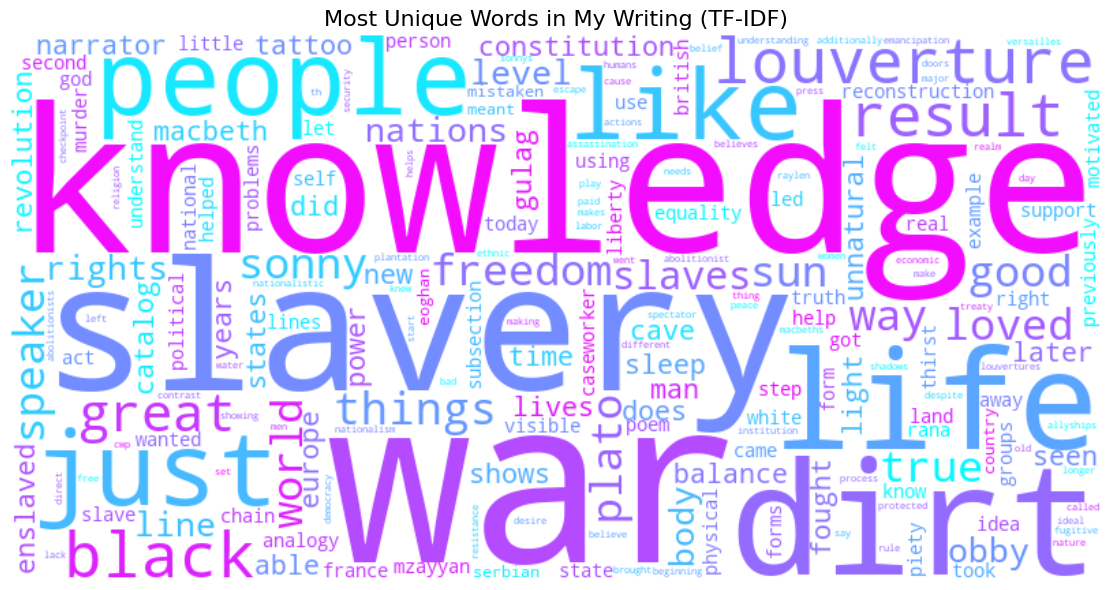

In [7]:
#word cloud of tf idf results
tfidf_freq = highesttfidf.to_dict()
tfidf_wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white',
    colormap='cool'
).generate_from_frequencies(tfidf_freq)
plt.figure(figsize=(12, 6))
plt.imshow(tfidf_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Unique Words in My Writing (TF-IDF)', fontsize=16)
plt.tight_layout()
plt.show()

#### Reflect on your findings. What patterns do you notice about your own academic writing style, vocabulary, themes, or repeated ideas?


I notice that I often write really broadly, with words like "people","like",'knowledge". Most of my essays also seem to be about history (slavery, abolish, etc.). Most of my essays (mostly academic) also seem to sound pretty rebotic (this happened to people, which resulted in this). 

TF-IDF matrix shape: (666, 500)


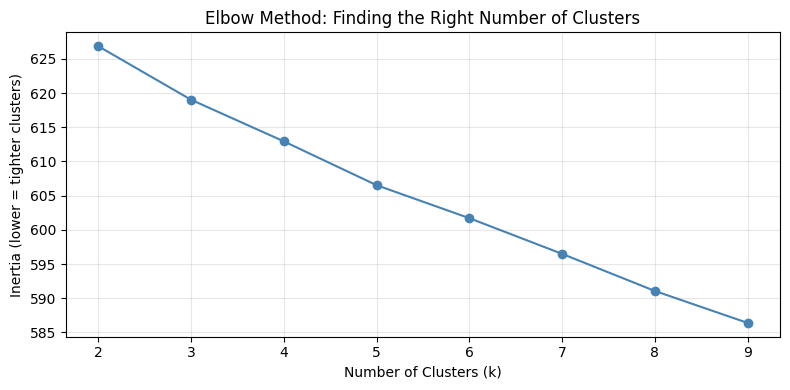

Look for the elbow — where the curve bends and flattens.
That k value is usually a good choice.

TOP WORDS PER CLUSTER

Cluster 0 (67 documents)
Top words: knowledge, sun, true, plato, light, line, cave, things, analogy, subsection
Your job: give this cluster a name based on these words!
----------------------------------------

Cluster 1 (549 documents)
Top words: war, slavery, life, louverture, sonny, people, body, black, macbeth, like
Your job: give this cluster a name based on these words!
----------------------------------------

Cluster 2 (50 documents)
Top words: dirt, speaker, man, tattoo, poem, lines, humans, shows, 13, like
Your job: give this cluster a name based on these words!
----------------------------------------

CLUSTER QUALITY METRICS

Silhouette Score: 0.022
  > 0.5 = strong clusters
  0.2-0.5 = reasonable clusters
  < 0.2 = weak or overlapping clusters

Davies-Bouldin Score: 5.146
  Closer to 0 = better separated clusters

Documents per cluster:
cluster
0     67
1

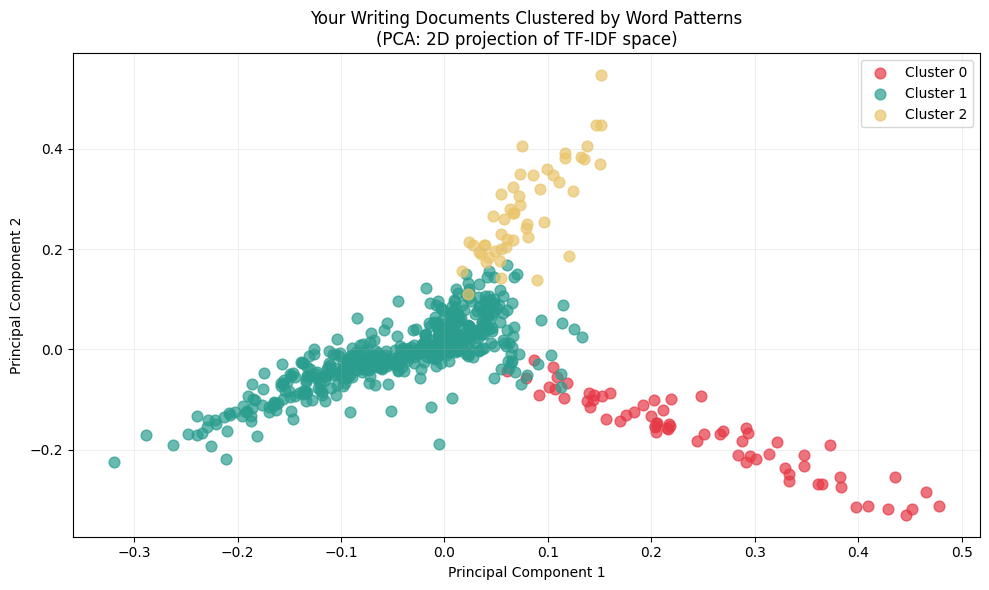

Each dot = one document. Dots close together = similar word patterns.

Similarity matrix shape: (666, 666)

Sample (first 4 documents vs first 4):
[[1.    0.176 0.298 0.   ]
 [0.176 1.    0.15  0.323]
 [0.298 0.15  1.    0.   ]
 [0.    0.323 0.    1.   ]]
Diagonal is always 1.0 — every document is identical to itself



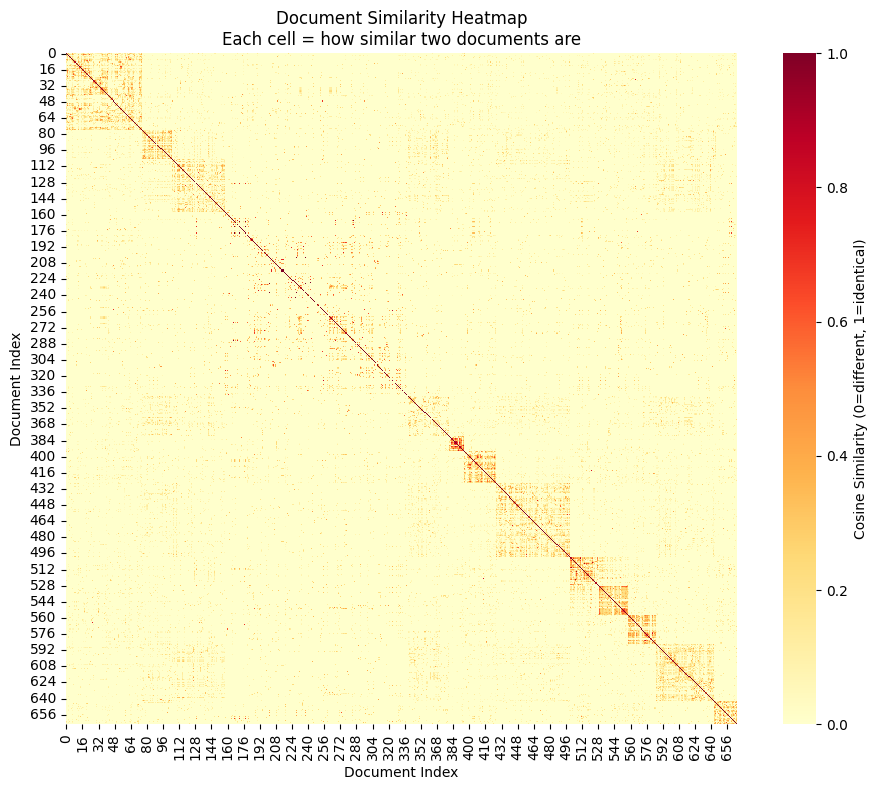

Bright red = very similar. Pale yellow = very different.

YOUR MOST SIMILAR DOCUMENT PAIR
Score: 1.000

Document 214:
  thirst must not overwhelm your desire to repent....

Document 215:
  thirst must not overwhelm your desire to repent....

Question: why do you think these two are so similar?

YOUR LEAST SIMILAR DOCUMENT PAIR
Score: 0.000

Document 0:
  ﻿allegory of the cave: implications of the analogies of the sun and line
by now we know that the chariot and charioteer represent the soul, and the resistance of the two horses is part of the journey to reach the forms....

Document 3:
  as a result, plato believes only philosophers are those who truly attain knowledge....

Question: what makes these two so different?

Source document [0]:
  ﻿allegory of the cave: implications of the analogies of the sun and line
by now we know that the chariot and charioteer represent the soul, and the resistance of the two horses is part of the journey to reach the forms....

Top 5 most similar docum

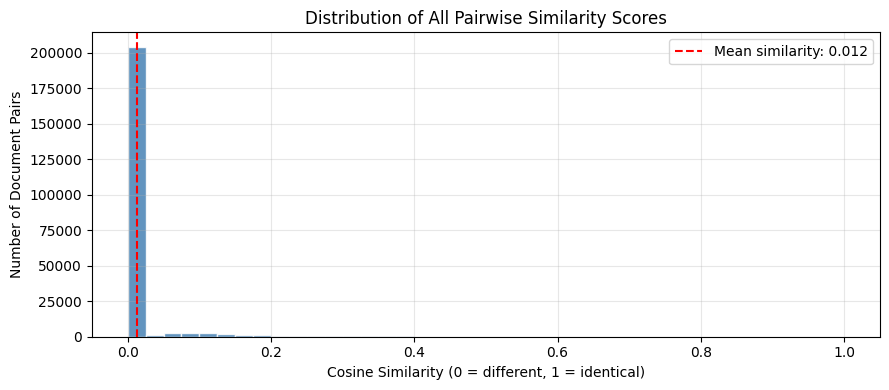

Average similarity across all pairs: 0.012
Most similar pair:  1.000
Least similar pair: 0.000

Reflection questions:
  - Is your writing more similar overall, or more varied?
  - Does this match your own sense of how diverse your topics are?
  - Which pair surprised you most?


In [9]:
# ============================================================
# FULL PIPELINE: K-MEANS CLUSTERING + COSINE SIMILARITY
# Starting point: you have df with 'clean_text' and tfidf_matrix
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics.pairwise import cosine_similarity

# ============================================================
# REBUILD TFIDF (skip if you already have tfidf_matrix + vectorizer)
# ============================================================

vectorizer = TfidfVectorizer(stop_words='english', max_features=500)
tfidf_matrix = vectorizer.fit_transform(df['cleantext'])
feature_names = vectorizer.get_feature_names_out()
print("TF-IDF matrix shape:", tfidf_matrix.shape)

# ============================================================
# SECTION 1: ELBOW METHOD — find the right number of clusters
# ============================================================

inertia_scores = []
cluster_range = range(2, 10)

for k in cluster_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(tfidf_matrix)
    inertia_scores.append(model.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(cluster_range, inertia_scores, marker='o', color='steelblue')
plt.title('Elbow Method: Finding the Right Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (lower = tighter clusters)')
plt.xticks(cluster_range)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("Look for the elbow — where the curve bends and flattens.")
print("That k value is usually a good choice.\n")

# ============================================================
# SECTION 2: RUN K-MEANS with your chosen number of clusters
# ============================================================

NUM_CLUSTERS = 3  # change this after looking at the elbow plot

kmeans = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init=10)
kmeans.fit(tfidf_matrix)
df['cluster'] = kmeans.labels_

# ============================================================
# SECTION 3: TOP WORDS PER CLUSTER
# ============================================================

print("=" * 50)
print("TOP WORDS PER CLUSTER")
print("=" * 50)

for cluster_num in range(NUM_CLUSTERS):
    center = kmeans.cluster_centers_[cluster_num]
    top_word_indices = center.argsort()[-10:][::-1]
    top_words = [feature_names[i] for i in top_word_indices]
    doc_count = (df['cluster'] == cluster_num).sum()
    print(f"\nCluster {cluster_num} ({doc_count} documents)")
    print(f"Top words: {', '.join(top_words)}")
    print("Your job: give this cluster a name based on these words!")
    print("-" * 40)

# ============================================================
# SECTION 4: CLUSTER METRICS
# ============================================================

sil = silhouette_score(tfidf_matrix, df['cluster'])
db = davies_bouldin_score(tfidf_matrix.toarray(), df['cluster'])

print("\n" + "=" * 50)
print("CLUSTER QUALITY METRICS")
print("=" * 50)
print(f"\nSilhouette Score: {sil:.3f}")
print("  > 0.5 = strong clusters")
print("  0.2-0.5 = reasonable clusters")
print("  < 0.2 = weak or overlapping clusters")
print(f"\nDavies-Bouldin Score: {db:.3f}")
print("  Closer to 0 = better separated clusters")
print(f"\nDocuments per cluster:")
print(df['cluster'].value_counts().sort_index())
print("If one cluster has 90% of documents, try a different k\n")

# ============================================================
# SECTION 5: SAMPLE DOCUMENTS FROM EACH CLUSTER
# ============================================================

print("=" * 50)
print("SAMPLE DOCUMENTS FROM EACH CLUSTER")
print("=" * 50)

for cluster_num in range(NUM_CLUSTERS):
    print(f"\n--- Cluster {cluster_num} ---")
    samples = df[df['cluster'] == cluster_num]['cleantext'].head(3)
    for i, text in enumerate(samples, 1):
        print(f"  [{i}] {text[:200]}...")

# ============================================================
# SECTION 6: PCA SCATTER PLOT — visualize clusters in 2D
# ============================================================

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(tfidf_matrix.toarray())

plot_df = pd.DataFrame({
    'x': coords[:, 0],
    'y': coords[:, 1],
    'cluster': df['cluster'].astype(str)
})

colors = ['#e63946', '#2a9d8f', '#e9c46a', '#457b9d', '#f4a261']

plt.figure(figsize=(10, 6))
for cluster_num in range(NUM_CLUSTERS):
    subset = plot_df[plot_df['cluster'] == str(cluster_num)]
    plt.scatter(subset['x'], subset['y'],
                label=f'Cluster {cluster_num}',
                alpha=0.7, s=60, color=colors[cluster_num])

plt.title('Your Writing Documents Clustered by Word Patterns\n(PCA: 2D projection of TF-IDF space)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()
print("Each dot = one document. Dots close together = similar word patterns.\n")

# ============================================================
# SECTION 7: BUILD COSINE SIMILARITY MATRIX
# ============================================================

similarity_matrix = cosine_similarity(tfidf_matrix)
print("Similarity matrix shape:", similarity_matrix.shape)
print(f"\nSample (first 4 documents vs first 4):")
print(np.round(similarity_matrix[:4, :4], 3))
print("Diagonal is always 1.0 — every document is identical to itself\n")

# ============================================================
# SECTION 8: SIMILARITY HEATMAP
# ============================================================

plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, cmap='YlOrRd', vmin=0, vmax=1,
            square=True,
            cbar_kws={'label': 'Cosine Similarity (0=different, 1=identical)'})
plt.title('Document Similarity Heatmap\nEach cell = how similar two documents are')
plt.xlabel('Document Index')
plt.ylabel('Document Index')
plt.tight_layout()
plt.show()
print("Bright red = very similar. Pale yellow = very different.\n")

# ============================================================
# SECTION 9: MOST AND LEAST SIMILAR DOCUMENT PAIRS
# ============================================================

sim_no_diagonal = similarity_matrix.copy()
np.fill_diagonal(sim_no_diagonal, 0)

most_similar_idx = np.unravel_index(np.argmax(sim_no_diagonal), sim_no_diagonal.shape)
doc_a, doc_b = most_similar_idx

sim_find_low = similarity_matrix.copy()
np.fill_diagonal(sim_find_low, 1)
least_similar_idx = np.unravel_index(np.argmin(sim_find_low), sim_find_low.shape)
doc_c, doc_d = least_similar_idx

print("=" * 50)
print("YOUR MOST SIMILAR DOCUMENT PAIR")
print("=" * 50)
print(f"Score: {similarity_matrix[doc_a][doc_b]:.3f}")
print(f"\nDocument {doc_a}:\n  {df['cleantext'].iloc[doc_a][:300]}...")
print(f"\nDocument {doc_b}:\n  {df['cleantext'].iloc[doc_b][:300]}...")
print("\nQuestion: why do you think these two are so similar?\n")

print("=" * 50)
print("YOUR LEAST SIMILAR DOCUMENT PAIR")
print("=" * 50)
print(f"Score: {similarity_matrix[doc_c][doc_d]:.3f}")
print(f"\nDocument {doc_c}:\n  {df['cleantext'].iloc[doc_c][:300]}...")
print(f"\nDocument {doc_d}:\n  {df['cleantext'].iloc[doc_d][:300]}...")
print("\nQuestion: what makes these two so different?\n")

# ============================================================
# SECTION 10: FIND MOST SIMILAR DOCUMENTS TO A GIVEN DOCUMENT
# ============================================================

def find_most_similar(doc_index, similarity_matrix, df, top_n=5):
    scores = similarity_matrix[doc_index]
    sorted_indices = scores.argsort()[::-1]
    similar_indices = [i for i in sorted_indices if i != doc_index][:top_n]

    print(f"Source document [{doc_index}]:")
    print(f"  {df['cleantext'].iloc[doc_index][:250]}...\n")
    print(f"Top {top_n} most similar documents:\n")

    for rank, idx in enumerate(similar_indices, 1):
        print(f"  [{rank}] Similarity: {scores[idx]:.3f}")
        print(f"       {df['cleantext'].iloc[idx][:200]}...")
        print()

find_most_similar(doc_index=0, similarity_matrix=similarity_matrix, df=df)

# ============================================================
# SECTION 11: SEARCH YOUR OWN WRITING WITH A NEW QUERY
# ============================================================

def search_my_writing(query_text, vectorizer, tfidf_matrix, df, top_n=5):
    # transform() uses the existing vocabulary — NOT fit_transform()
    # fit_transform() would learn a new vocabulary from your query alone
    query_vector = vectorizer.transform([query_text])
    query_similarities = cosine_similarity(query_vector, tfidf_matrix)[0]
    top_indices = query_similarities.argsort()[::-1][:top_n]

    print(f"Query: '{query_text}'")
    print(f"\nMost similar passages in your writing:\n")

    for rank, idx in enumerate(top_indices, 1):
        score = query_similarities[idx]
        if score == 0:
            print(f"  [{rank}] No similarity found (score: 0.000)")
            print(f"       This word may not be in your writing vocabulary")
        else:
            print(f"  [{rank}] Similarity: {score:.3f}")
            print(f"       {df['cleantext'].iloc[idx][:250]}...")
        print()

# Change this query to anything you want to search for in your writing
search_my_writing(
    query_text="climate change and environmental policy",
    vectorizer=vectorizer,
    tfidf_matrix=tfidf_matrix,
    df=df
)

# ============================================================
# SECTION 12: DISTRIBUTION OF ALL PAIRWISE SIMILARITY SCORES
# ============================================================

upper_triangle_indices = np.triu_indices_from(similarity_matrix, k=1)
all_pair_scores = similarity_matrix[upper_triangle_indices]

plt.figure(figsize=(9, 4))
plt.hist(all_pair_scores, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(np.mean(all_pair_scores), color='red', linestyle='--',
            label=f'Mean similarity: {np.mean(all_pair_scores):.3f}')
plt.title('Distribution of All Pairwise Similarity Scores')
plt.xlabel('Cosine Similarity (0 = different, 1 = identical)')
plt.ylabel('Number of Document Pairs')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Average similarity across all pairs: {np.mean(all_pair_scores):.3f}")
print(f"Most similar pair:  {np.max(all_pair_scores):.3f}")
print(f"Least similar pair: {np.min(all_pair_scores):.3f}")
print()
print("Reflection questions:")
print("  - Is your writing more similar overall, or more varied?")
print("  - Does this match your own sense of how diverse your topics are?")
print("  - Which pair surprised you most?")